### Calculating Horizontal Gaze Angle

ARKit uses Euler matrices to express rotation in 3D space. The eye-transform matrix tells us, "if you want to take a point in head space and transform it into eye space, multiply it by this matrix". The caveat being that the last column says where the eye origin is relative to the head origin, i.e. it will translate the original point. [According to Apple](https://developer.apple.com/documentation/arkit/arfaceanchor#Tracking-Face-Position-and-Orientation) the $Z$ axis of the eye is where the eye is looking. So, to get the horizontal gaze angle we can ask, "where is the $Z$ axis of the head space rotated to after applying the eye transform, and what angle does it make with the original $Z$ axis?". This is equivalent to applying the eye transform matrix to the vector $[0, 0, 1, 0]'$ which will tell us where the $Z$ axis ends up. Then we can ignore the $Y$ and translational components of the result since we only care about position in the $X$,$Z$ plane. This gives us an ($X$, $Z$) coordinate in the $X$,$Z$ plane. We know that 

$$ 
tan(\theta) = X/Z 
$$ 

where $\theta$ is more positive the farther the user looks to the left, since the $X$ axis points to their left. We want rightward to be positive so we can calculate our desired $\theta$ by negating the angle using 

$$
\theta = -tan^{-1}(X/Z)
$$

In [1]:
from dataclasses import dataclass
from enum import Enum
import math
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from pydantic import BaseModel

In [2]:
class Transforms(BaseModel):
    head: list[list[list[float]]]
    left_eye: list[list[list[float]]]
    right_eye: list[list[list[float]]]

In [3]:
DATA_DIR = Path("./data")
TRANSFORMS_DIR = DATA_DIR / "transforms"

In [4]:
session_id = "3ba72673-499e-4c31-ba51-e74ba9dbf4a5"
transforms_path = TRANSFORMS_DIR / f"{session_id}.json"
transforms = Transforms.model_validate_json(transforms_path.read_bytes())

In [5]:
class Direction(Enum):
    Horizontal = 1
    Vertical = 2

@dataclass
class ByEye:
    left: np.ndarray
    right: np.ndarray

@dataclass
class GazeAngles:
    horizontal: ByEye
    vertical: ByEye


def _extract_angle_single_eye(transforms: list[list[list[float]]], direction: Direction) -> np.ndarray:
    transforms_array = np.array(transforms)
    unit_z = np.array([0, 0, 1, 0])
    transformed_z = transforms_array @ unit_z.T
    # Extract the Z dimension and either the X or Y dimension depending on
    # whether we are calculating the horizontal or vertical angle. X for
    # horizontal (dim 0) and Y for vertical (dim 1).
    non_z_index = 0 if direction == Direction.Horizontal else 1
    two_d = transformed_z[:, [non_z_index, 2]]
    arc_tan = np.vectorize(math.atan)
    # Calculate opposite over adjacent
    ratio = two_d[:, 0] / two_d[:, 1]
    angles_radians = -arc_tan(ratio)
    angles_degrees = angles_radians * 180 / math.pi
    return angles_degrees

def extract_angle(transforms: Transforms) -> GazeAngles:
    return GazeAngles(
        horizontal=ByEye(
            left=_extract_angle_single_eye(transforms.left_eye, Direction.Horizontal),
            right=_extract_angle_single_eye(transforms.right_eye, Direction.Horizontal),
        ),
        vertical=ByEye(
            left=_extract_angle_single_eye(transforms.left_eye, Direction.Vertical),
            right=_extract_angle_single_eye(transforms.right_eye, Direction.Vertical),
        ),
    )

In [16]:
def _single_plot(angles: np.ndarray, title: str, ax: plt.Axes):
    ax.plot(angles)
    ax.set_title(title)
    ax.set_yticks([-60, -55, -45, -30, -15, 0, 15, 30, 45, 55, 60])
    ax.set_yticklabels(["-60°", "-55°", "-45°", "-30°", "-15°", "0°", "15°", "30°", "45°", "55°", "60°"])
    ax.grid(axis="y")

def plot_angles(angles: GazeAngles):
    fig, axes = plt.subplots(2, 2, figsize=(20, 10))
    _single_plot(angles.horizontal.left, "Left - Horizontal", axes[0][0])
    _single_plot(angles.vertical.left, "Left - Vertical", axes[1][0])
    _single_plot(angles.horizontal.right, "Right - Horizontal", axes[0][1])
    _single_plot(angles.vertical.right, "Right - Vertical", axes[1][1])


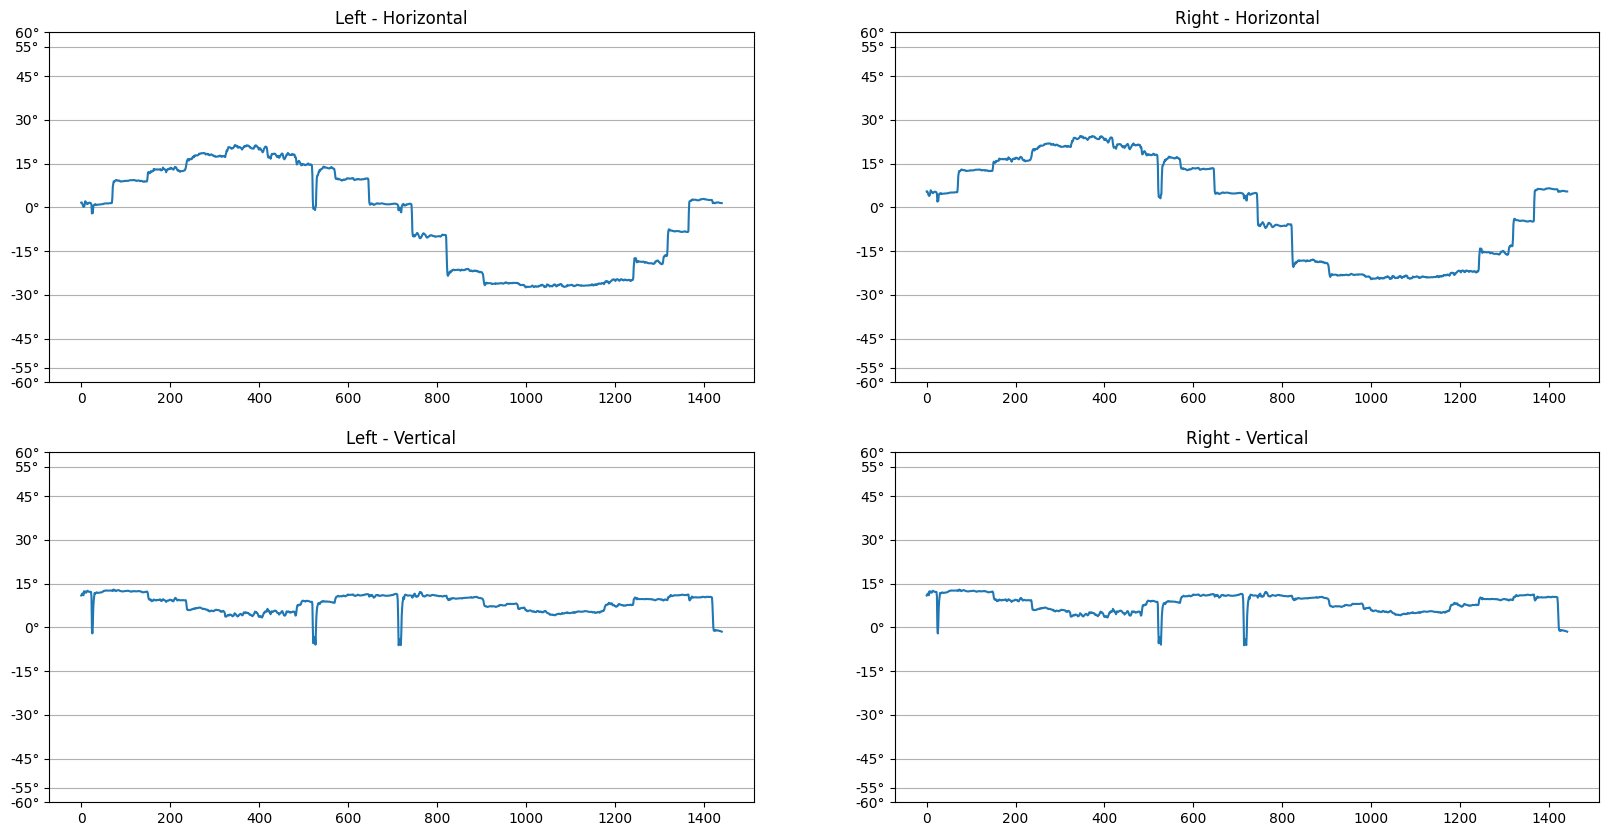

In [17]:
angles = extract_angle(transforms)
plot_angles(angles)

In [6]:
left_eye = np.array(transforms.left_eye)
left_eye.shape
 

(281, 4, 4)

In [9]:
left_eye[0]

array([[ 1.0000000e+00, -3.6035976e-06, -2.7245790e-04,  0.0000000e+00],
       [ 0.0000000e+00,  9.9991250e-01, -1.3225098e-02,  0.0000000e+00],
       [ 2.7248173e-04,  1.3225098e-02,  9.9991250e-01,  0.0000000e+00],
       [ 3.1966366e-02,  3.0724604e-02,  2.4759667e-02,  1.0000000e+00]])

In [8]:
left_eye[0].T

array([[ 1.0000000e+00,  0.0000000e+00,  2.7248173e-04,  3.1966366e-02],
       [-3.6035976e-06,  9.9991250e-01,  1.3225098e-02,  3.0724604e-02],
       [-2.7245790e-04, -1.3225098e-02,  9.9991250e-01,  2.4759667e-02],
       [ 0.0000000e+00,  0.0000000e+00,  0.0000000e+00,  1.0000000e+00]])

In [12]:
left_eye[1]

array([[ 1.0000000e+00, -1.6913966e-06, -1.2695108e-04,  0.0000000e+00],
       [ 0.0000000e+00,  9.9991130e-01, -1.3322033e-02,  0.0000000e+00],
       [ 1.2696235e-04,  1.3322033e-02,  9.9991130e-01,  0.0000000e+00],
       [ 3.1966366e-02,  3.0724604e-02,  2.4759667e-02,  1.0000000e+00]])

In [14]:
unit_z = np.array([0, 0, 1, 0])
transformed_z = left_eye @ unit_z.T
x_z = transformed_z[:, [0, 2]]
x_z.shape

(281, 2)

In [32]:
x_z

array([[-2.72457900e-04,  9.99912500e-01],
       [-1.26951080e-04,  9.99911300e-01],
       [-1.77437740e-05,  9.99913040e-01],
       [-3.96411100e-04,  9.99915800e-01],
       [-1.08230100e-03,  9.99932000e-01],
       [-1.35188120e-03,  9.99936500e-01],
       [-1.39017700e-03,  9.99937060e-01],
       [-1.24128940e-03,  9.99934500e-01],
       [-1.58554870e-03,  9.99930260e-01],
       [-1.89121790e-03,  9.99924200e-01],
       [-2.24943830e-03,  9.99925200e-01],
       [-2.53562230e-03,  9.99909800e-01],
       [-3.18111970e-03,  9.99878640e-01],
       [-2.91432930e-03,  9.99878700e-01],
       [-2.61662390e-03,  9.99862800e-01],
       [-2.49687560e-03,  9.99839600e-01],
       [-2.37905700e-03,  9.99830500e-01],
       [-2.52492730e-03,  9.99820950e-01],
       [-2.71837460e-03,  9.99815000e-01],
       [-2.63551860e-03,  9.99811700e-01],
       [-2.34066930e-03,  9.99802100e-01],
       [-2.36336420e-03,  9.99800560e-01],
       [-2.12856780e-03,  9.99808300e-01],
       [-2.

In [39]:
arc_tan = np.vectorize(math.atan)
x_over_z = x_z[:, 0] / x_z[:, 1]
angles_radians = -arc_tan(x_over_z)
angles_degrees = angles_radians * 180 / math.pi

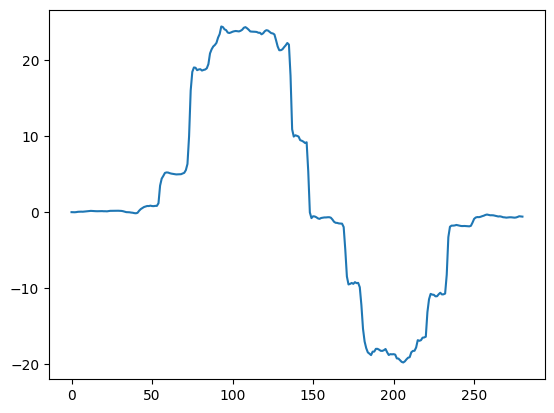

In [40]:
plt.plot(angles_degrees)